In [1]:
import numpy as np
import pandas as pd
import fastf1 as ff1

In [2]:
import os

data_dir = './f1_data'
race_file = os.path.join(data_dir, 'f1_strategy_NN_XGB_19_25_encoded.csv')
df_race = pd.read_csv(race_file)

### REGRESSOR V5

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# APPLY MASK FOR XGBOOST (Pure Pace)
# ---------------------------------------------------------
# We only want clean laps to learn pure tyre degradation and fuel burn.
xgb_training_mask = (
    (df_race['LapNumber'] > 1) & 
    (df_race['InPits'] == False) & 
    (df_race['LapDeltaSeconds'] < 12.0) & 
    (df_race['LapDeltaSeconds'] > -3.0) &
    (df_race['CleanTrackStatus_GreenFlag'] == 1) # Added the Green Flag filter!
)
df_xgb = df_race[xgb_training_mask].copy()

# ---------------------------------------------------------
# DEFINE COLUMNS TO KEEP
# ---------------------------------------------------------
# XGBoost columns to keep + Driver One-Hot columns
driver_cols = [col for col in df_xgb.columns if col.startswith('Driver_')]

xgb_cols_to_keep = [
    'LapNumber',
    'Position',
    'TrackTemp', 
    'RaceProgress',
    'TyreLifeProgress', 
    'TyreLifeProgress_Squared',
    'TrackType',
    'TwoTyreCompoundsUsed',
    'CarClose',
    'ConstructorChampionshipPosition',
    'Compound_HARD', 
    'Compound_MEDIUM', 
    'Compound_SOFT'
]

# ---------------------------------------------------------
# TEMPORAL SPLIT (Match Neural Network's Test Set)
# ---------------------------------------------------------
# Identify the test year (same as we did for the Neural Network)
test_year = df_xgb['Year'].max()

# Create masks to separate historical data from unseen test data
train_val_mask = df_xgb['Year'] < test_year
test_mask = df_xgb['Year'] == test_year

df_train_val_xgb_2 = df_xgb[train_val_mask].copy()
df_test_xgb_2 = df_xgb[test_mask].copy()

# ---------------------------------------------------------
# DEFINE FEATURES (X) AND TARGET (y)
# ---------------------------------------------------------
# THIS WAS THE MISSING PART: We apply 'xgb_cols_to_keep' to create our X matrices
X_train_val_xgb_2 = df_train_val_xgb_2[xgb_cols_to_keep]
X_test_xgb_2 = df_test_xgb_2[xgb_cols_to_keep]

# The target is the delta we calculated earlier
y_train_val_xgb_2 = df_train_val_xgb_2['LapDeltaSeconds']
y_test_xgb_2 = df_test_xgb_2['LapDeltaSeconds']

# ---------------------------------------------------------
# SPLIT TRAIN AND VALIDATION SETS
# ---------------------------------------------------------
# We split the historical data into Train (80%) and Validation (20%)
# for XGBoost early stopping
X_train_xgb_2, X_valid_xgb_2, y_train_xgb_2, y_valid_xgb_2 = train_test_split(
    X_train_val_xgb_2, y_train_val_xgb_2, 
    test_size=0.2, 
    random_state=42
)

print(f"✅ XGBoost Data ready! Features: {X_train_xgb_2.shape[1]}, Train rows: {len(X_train_xgb_2)}")
print(f"Train samples: {X_train_xgb_2.shape[0]} | Validation samples: {X_valid_xgb_2.shape[0]} | Test samples: {X_test_xgb_2.shape[0]}")

✅ XGBoost Data ready! Features: 13, Train rows: 64958
Train samples: 64958 | Validation samples: 16240 | Test samples: 15613


In [4]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# ---------------------------------------------------------
# DEFINE THE PARAMETER GRID
# ---------------------------------------------------------
# Sensible range for each hyperparameter.
param_distributions = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [1000, 1500, 2000, 2500],
    'reg_lambda': [0.5, 1.0, 5.0],
    'reg_alpha': [0.0, 0.1, 0.5]
}

# ---------------------------------------------------------
# INITIALIZE THE BASE MODEL
# ---------------------------------------------------------
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
)

# ---------------------------------------------------------
# SETUP RANDOMIZED SEARCH
# ---------------------------------------------------------
# We test 15 random combinations. Increase n_iter if you have time/CPU power!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=25, 
    scoring='neg_mean_absolute_error', # We optimize specifically for MAE
    cv=3,                              # 3-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1                          # Use all CPU cores for the search
)

# ---------------------------------------------------------
# RUN THE SEARCH
# ---------------------------------------------------------
print("🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...")

# We use the combined Train + Validation set. 
# The 'cv=3' argument will automatically split it during the search.
random_search.fit(X_train_val_xgb_2, y_train_val_xgb_2)

# ---------------------------------------------------------
# PRINT THE BEST RESULTS
# ---------------------------------------------------------
print("\n✅ Search Completed!")
print(f"🏆 Best Parameters Found:\n{random_search.best_params_}")
print(f"📊 Best Cross-Validation MAE: {-random_search.best_score_:.3f} seconds")

# Retrieve the absolute best model from the search
best_xgb_model = random_search.best_estimator_

🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Search Completed!
🏆 Best Parameters Found:
{'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
📊 Best Cross-Validation MAE: 0.725 seconds


In [5]:
import joblib

# ---------------------------------------------------------
# SAVE THE OPTIMIZED XGBOOST MODEL
# ---------------------------------------------------------
# We save the model found by RandomizedSearch
xgb_filename = 'f1_pace_model_v5_optimized.joblib'

try:
    joblib.dump(best_xgb_model, xgb_filename)
    print(f"✅ XGBoost model successfully saved as '{xgb_filename}'")
except Exception as e:
    print(f"❌ Error saving the model: {e}")

# ---------------------------------------------------------
# VERIFY THE SAVE (Optional)
# ---------------------------------------------------------
# Let's try to reload it to ensure integrity
loaded_model = joblib.load(xgb_filename)
print("🔍 Integrity check: Model reloaded successfully.")

# Quick test prediction to compare with the original
test_pred_original = best_xgb_model.predict(X_test_xgb_2.head(1))
test_pred_loaded = loaded_model.predict(X_test_xgb_2.head(1))

if np.isclose(test_pred_original, test_pred_loaded):
    print("💎 Validation passed: Predictions match perfectly!")

✅ XGBoost model successfully saved as 'f1_pace_model_v5_optimized.joblib'
🔍 Integrity check: Model reloaded successfully.
💎 Validation passed: Predictions match perfectly!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_xgb_feature_importance(model, feature_names, top_n=15, title="XGBoost Feature Importance"):
    """
    Plots the feature importance of an XGBoost model.
    
    Parameters:
    - model: The trained XGBoost model.
    - feature_names: List or Index of feature names (e.g., X_train.columns).
    - top_n: Number of top features to display.
    - title: Title of the chart.
    """
    # ---------------------------------------------------------
    # EXTRACT AND MAPPING
    # ---------------------------------------------------------
    # Get importance scores
    importances = model.feature_importances_
    
    # Create a DataFrame for easy sorting
    df_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Sort by importance descending
    df_importance = df_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    # ---------------------------------------------------------
    # VISUALIZATION
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    # Use a color palette that highlights the most important features
    sns.barplot(
        data=df_importance.head(top_n), 
        x='Importance', 
        y='Feature', 
        palette='magma'
    )
    
    plt.title(title, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Relative Importance Score (Gain/Weight)", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Print the top 5 for a quick numerical check
    print(f"\nTop 5 Features for {title}:")
    print(df_importance.head(5).to_string(index=False))
    
    return df_importance # Returns the full dataframe if you need to perform further analysis

# ---------------------------------------------------------
# EXAMPLE USAGE:
# ---------------------------------------------------------
# importance_df = plot_xgb_feature_importance(best_xgb_model, X_train.columns)

C:\Users\lucam\AppData\Local\Temp\ipykernel_25428\2530003335.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


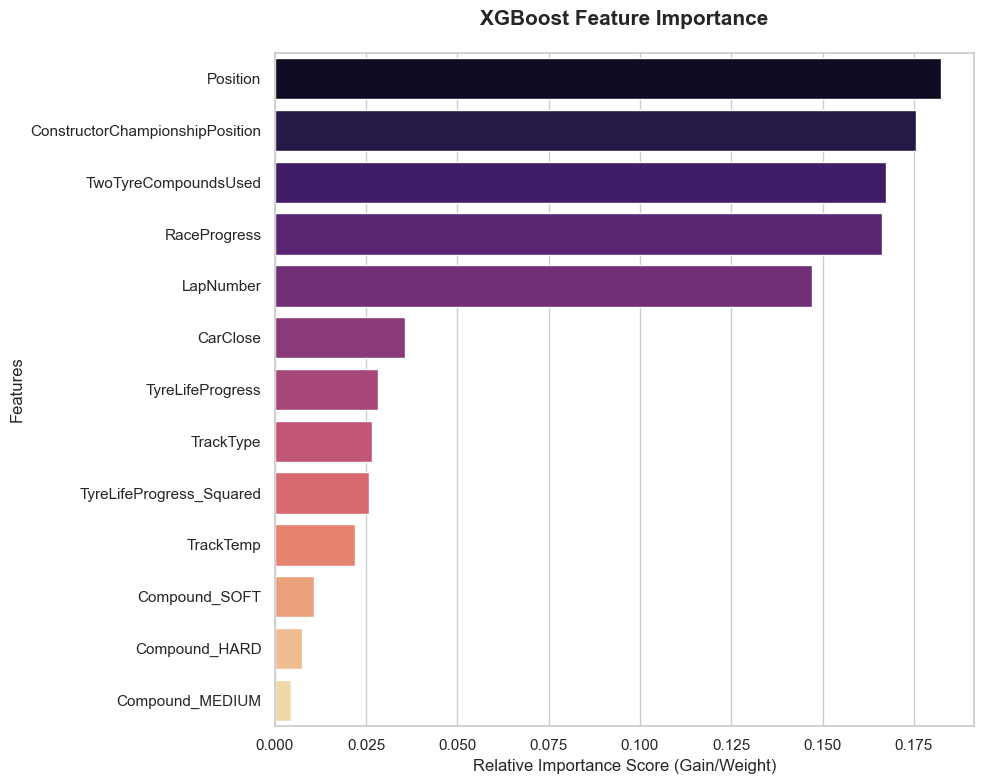


Top 5 Features for XGBoost Feature Importance:
                        Feature  Importance
                       Position    0.182344
ConstructorChampionshipPosition    0.175714
           TwoTyreCompoundsUsed    0.167293
                   RaceProgress    0.166372
                      LapNumber    0.147214


,Feature,Importance
0,Position,0.182344
1,ConstructorChampionshipPosition,0.175714
2,TwoTyreCompoundsUsed,0.167293
3,RaceProgress,0.166372
4,LapNumber,0.147214
5,CarClose,0.035784
6,TyreLifeProgress,0.028332
7,TrackType,0.026613
8,TyreLifeProgress_Squared,0.025785
9,TrackTemp,0.022029


In [7]:
plot_xgb_feature_importance(best_xgb_model, X_train_xgb_2.columns)

In [7]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------------------------------------------
# DEFINE THE PARAMETER GRID
# ---------------------------------------------------------
# Sensible range for each hyperparameter.
param_distributions = {
    'learning_rate': [0.01, 0.02, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'n_estimators': [300, 500, 800,1000, 1200],
    'reg_lambda': [0.5, 1.0, 5.0],
    'reg_alpha': [0.0, 0.1, 0.5]
}

# ---------------------------------------------------------
# INITIALIZE THE BASE MODEL
# ---------------------------------------------------------
xgb_base = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
)

# ---------------------------------------------------------
# SETUP RANDOMIZED SEARCH
# ---------------------------------------------------------
# We test 15 random combinations. Increase n_iter if you have time/CPU power!
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=25, 
    scoring='neg_mean_absolute_error', # We optimize specifically for MAE
    cv=3,                              # 3-Fold Cross Validation
    verbose=2,
    random_state=42,
    n_jobs=-1                          # Use all CPU cores for the search
)

# ---------------------------------------------------------
# RUN THE SEARCH
# ---------------------------------------------------------
print("🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...")

# We use the combined Train + Validation set. 
# The 'cv=3' argument will automatically split it during the search.
random_search.fit(X_train_val_xgb_2, y_train_val_xgb_2)

# ---------------------------------------------------------
# PRINT THE BEST RESULTS
# ---------------------------------------------------------
print("\n✅ Search Completed!")
print(f"🏆 Best Parameters Found:\n{random_search.best_params_}")
print(f"📊 Best Cross-Validation MAE: {-random_search.best_score_:.3f} seconds")

# Retrieve the absolute best model from the search
best_xgb_model = random_search.best_estimator_

🟢 Starting Randomized Search (Grab a coffee, this will take a few minutes)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

✅ Search Completed!
🏆 Best Parameters Found:
{'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.0, 'n_estimators': 800, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
📊 Best Cross-Validation MAE: 0.706 seconds


C:\Users\lucam\AppData\Local\Temp\ipykernel_13464\2530003335.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


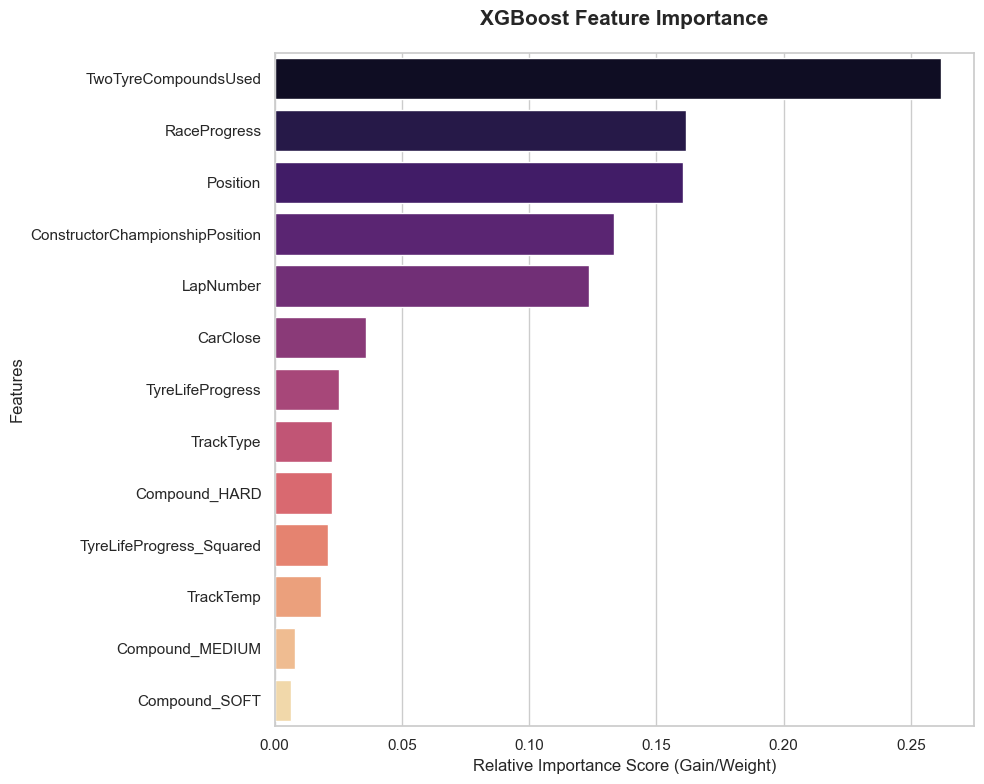


Top 5 Features for XGBoost Feature Importance:
                        Feature  Importance
           TwoTyreCompoundsUsed    0.261765
                   RaceProgress    0.161649
                       Position    0.160640
ConstructorChampionshipPosition    0.133268
                      LapNumber    0.123381


,Feature,Importance
0,TwoTyreCompoundsUsed,0.261765
1,RaceProgress,0.161649
2,Position,0.160640
3,ConstructorChampionshipPosition,0.133268
4,LapNumber,0.123381
5,CarClose,0.035768
6,TyreLifeProgress,0.025204
7,TrackType,0.022639
8,Compound_HARD,0.022429
9,TyreLifeProgress_Squared,0.020963


In [8]:
plot_xgb_feature_importance(best_xgb_model, X_train_xgb_2.columns)

### SIMULATION

In [8]:
import tensorflow as tf
import joblib

# ---------------------------------------------------------
# LOAD THE NEURAL NETWORK MODEL V3
# ---------------------------------------------------------
nn_model = tf.keras.models.load_model('f1_strategic_model_m10_v3.keras')

# ---------------------------------------------------------
# LOAD THE OPTIMIZED XGBOOST MODEL V4
# ---------------------------------------------------------
best_xgb_model = joblib.load('f1_pace_model_v5_optimized.joblib')

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------------------------------------
# SPLIT DATA (Train, Validation, Test)
# ---------------------------------------------------------
# We use the most recent year in your dataset as the unseen Test Set (2025)
test_year = df_race['Year'].max()

# Create masks to separate the data
train_val_mask = df_race['Year'] < test_year
test_mask = df_race['Year'] == test_year

df_train_val_nn = df_race[train_val_mask].copy()
df_test_nn = df_race[test_mask].copy()

# Features for the neural network
nn_cols_to_keep = [
    'Position', 
    'TrackTemp', 
    'RaceProgress', 
    'TyreLifeProgress', 
    'CarClose', 
    'PitStopBehind', 
    'TwoTyreCompoundsUsed', 
    'TrackType', 
    'ConstructorChampionshipPosition', 
    'Compound_HARD', 
    'Compound_MEDIUM', 
    'Compound_SOFT', 
    'CleanTrackStatus_GreenFlag', 
    'CleanTrackStatus_RedFlag', 
    'CleanTrackStatus_SafetyCar', 
    'CleanTrackStatus_VSC', 
    'CleanTrackStatus_YellowFlag'
]

X_train_val_nn = df_train_val_nn[nn_cols_to_keep]
y_train_val_nn = df_train_val_nn['InPits']

X_test_nn = df_test_nn[nn_cols_to_keep]
y_test_nn = df_test_nn['InPits']

# Split the historical data into Train (80%) and Validation (20%)
# stratify=y_train_val ensures both sets have the same ~3% ratio of pit stops
X_train_nn, X_valid_nn, y_train_nn, y_valid_nn = train_test_split(
    X_train_val_nn, y_train_val_nn,
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_val_nn
)

print(f"Features ready for the Neural Network: {X_train_nn.shape[1]}")
print(f"Train samples: {X_train_nn.shape[0]} | Validation samples: {X_valid_nn.shape[0]} | Test samples: {X_test_nn.shape[0]}")

Features ready for the Neural Network: 17
Train samples: 75192 | Validation samples: 18799 | Test samples: 17824


In [10]:
nn_features = X_train_nn.columns.tolist()
xgb_features = X_train_xgb_2.columns.tolist()

In [11]:
# =====================================================================
# 4. SAFETY CAR / VSC PROBABILITY MATRIX (STOCHASTIC BINNING)
# =====================================================================
# We divide the race into 20 segments (bins) of 5% RaceProgress each.
# This identifies "High Risk" zones (e.g., Start, Pit Windows).
bins = np.arange(0, 1.05, 0.05)
df_race['ProgressBin'] = pd.cut(df_race['RaceProgress'], bins=bins)

# Calculate the mean frequency of neutralizations per bin
sc_prob_matrix = df_race.groupby('ProgressBin', observed=False)[['CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC']].mean()
# Combined probability for any track neutralization
sc_prob_matrix['Neutralization_Prob'] = sc_prob_matrix['CleanTrackStatus_SafetyCar'] + sc_prob_matrix['CleanTrackStatus_VSC']

print("🚨 Top 5 High-Risk Race Segments (Safety Car/VSC Probability):")
print(sc_prob_matrix['Neutralization_Prob'].sort_values(ascending=False).head(5))

🚨 Top 5 High-Risk Race Segments (Safety Car/VSC Probability):
ProgressBin
(0.0, 0.05]    0.151854
(0.75, 0.8]    0.090011
(0.7, 0.75]    0.077547
(0.8, 0.85]    0.067345
(0.9, 0.95]    0.066606
Name: Neutralization_Prob, dtype: float64


In [12]:
import pandas as pd
import numpy as np
import copy

def run_stochastic_dynamic_strategy_test(df_master, gp_name, driver_code, year, nn_model, xgb_model, xgb_features, nn_features, sc_prob_matrix):
    """
    Simulazione Monte Carlo (Expected Value) della strategia F1.
    L'IA non conosce il futuro, ma calcola il rischio statistico di Safety Car/VSC.
    Include Veto di Rete Neurale, Bonus Reazione Rapida e XAI (Explainability).
    """
    driver_col = f'Driver_{driver_code}'
    race_data = df_master[(df_master['GP'] == gp_name) & 
                          (df_master['Year'] == year) & 
                          (df_master[driver_col] == 1)].sort_values('LapNumber').copy()
    
    if race_data.empty: return None

    # ==========================================
    # ⚙️ COSTANTI STRATEGICHE (HARDCODED)
    # ==========================================
    # CLIFF_LAPS = {'SOFT': 22, 'MEDIUM': 38, 'HARD': 55} 
    CLIFF_LAPS = {'SOFT': 28, 'MEDIUM': 40, 'HARD': 50}    
    NORMAL_PIT_LOSS = 24.0
    SC_PIT_LOSS = 14.0
    MAX_TYRE_LIFE = 40.0
    NN_PIT_THRESHOLD = 0.45 
    NN_VETO_THRESHOLD = 0.70 # SOGLIA VETO
    SC_AVERAGE_LAPS = 3 
    
    prob_dict = {interval: prob for interval, prob in sc_prob_matrix['Neutralization_Prob'].items()}

    start_comp = 'MEDIUM'
    if race_data.iloc[0]['Compound_SOFT'] == 1: start_comp = 'SOFT'
    elif race_data.iloc[0]['Compound_HARD'] == 1: start_comp = 'HARD'

    prediction_cache = {}

    def evaluate_action_to_finish(start_idx, base_state, action_this_lap, sc_active_now, is_new_sc):
        state = copy.deepcopy(base_state)
        projected_time = 0.0
        
        # 1. AZIONE IMMEDIATA
        if "BOX" in action_this_lap:
            new_comp = action_this_lap.split("_")[1]
            if sc_active_now:
                pit_cost = (SC_PIT_LOSS - 2.0) if is_new_sc else SC_PIT_LOSS
            else:
                pit_cost = NORMAL_PIT_LOSS
                
            projected_time += pit_cost
            state['current_compound'] = new_comp
            state['tyre_age'] = 0
            state['compounds_used'].add(new_comp)
        
        simulated_sc_laps_left = SC_AVERAGE_LAPS if sc_active_now else 0

        # 2. PROIEZIONE "CIECA" SUL FUTURO
        for j in range(start_idx, len(race_data)):
            has_two_comps = 1 if len(state['compounds_used']) > 1 else 0
            current_progress = race_data.iloc[j]['RaceProgress']
            
            if simulated_sc_laps_left > 0:
                sc_probability = 1.0
                simulated_sc_laps_left -= 1
            else:
                sc_probability = 0.05 
                for interval, prob in prob_dict.items():
                    if current_progress in interval:
                        sc_probability = prob
                        break
            
            cache_key = (j, state['tyre_age'], state['current_compound'], has_two_comps)
            if cache_key in prediction_cache:
                base_pace, nn_prob = prediction_cache[cache_key]
            else:
                lap_df = race_data.iloc[[j]].copy()
                lap_df['CleanTrackStatus_SafetyCar'] = 0
                lap_df['CleanTrackStatus_VSC'] = 0
                
                tyre_prog = state['tyre_age'] / MAX_TYRE_LIFE
                lap_df['TyreLifeProgress'] = tyre_prog
                lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
                lap_df['Compound_SOFT'] = 1 if state['current_compound'] == 'SOFT' else 0
                lap_df['Compound_MEDIUM'] = 1 if state['current_compound'] == 'MEDIUM' else 0
                lap_df['Compound_HARD'] = 1 if state['current_compound'] == 'HARD' else 0
                lap_df['TwoTyreCompoundsUsed'] = has_two_comps
                
                base_pace = xgb_model.predict(lap_df[xgb_features])[0]
                nn_prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]
                prediction_cache[cache_key] = (base_pace, nn_prob)

            if state['tyre_age'] <= 1:
                base_pace = min(base_pace, 3.0)
                
            pace_if_green = base_pace
            pace_if_sc = base_pace + 35.0 
            
            expected_pace = (pace_if_green * (1 - sc_probability)) + (pace_if_sc * sc_probability)
            projected_time += expected_pace
            
            if state['tyre_age'] > CLIFF_LAPS[state['current_compound']]:
                projected_time += (state['tyre_age'] - CLIFF_LAPS[state['current_compound']]) * 2.5
                
            if nn_prob > NN_PIT_THRESHOLD or state['tyre_age'] >= CLIFF_LAPS[state['current_compound']]:
                expected_pit_cost = (NORMAL_PIT_LOSS * (1 - sc_probability)) + (SC_PIT_LOSS * sc_probability)
                projected_time += expected_pit_cost
                
                #next_comp = 'HARD' if 'HARD' not in state['compounds_used'] else 'MEDIUM'
                remaining = [c for c in ['HARD', 'MEDIUM', 'SOFT'] 
                             if c not in state['compounds_used'] 
                             and c != state['current_compound']]
                next_comp = remaining[0] if remaining else ('MEDIUM' if state['current_compound'] != 'MEDIUM' else 'HARD')

                state['current_compound'] = next_comp
                state['tyre_age'] = 0
                state['compounds_used'].add(next_comp)
            else:
                state['tyre_age'] += 1
                
        if len(state['compounds_used']) < 2: projected_time += 999.0 
        
        return projected_time

    # ---------------------------------------------------------
    # REALITY: IL CICLO DELLA GARA VERA
    # ---------------------------------------------------------
    real_state = {
        'current_compound': start_comp,
        'tyre_age': 0,
        'compounds_used': {start_comp}
    }
    
    simulation_logs = []
    
    print(f"\n🟢 INIZIO GARA: {gp_name} ({year}) | Pilota: {driver_code} | Mescola Partenza: {start_comp}")
    print("-" * 60)
    
    for i in range(len(race_data)):
        lap_df = race_data.iloc[[i]].copy()
        lap_num = int(lap_df['LapNumber'].iloc[0])

        is_sc = int(lap_df['CleanTrackStatus_SafetyCar'].iloc[0]) == 1
        is_vsc = int(lap_df['CleanTrackStatus_VSC'].iloc[0]) == 1
        is_sc_now = is_sc or is_vsc
        
        was_sc_prev = False
        if i > 0:
            prev_lap = race_data.iloc[[i-1]]
            was_sc_prev = int(prev_lap['CleanTrackStatus_SafetyCar'].iloc[0]) == 1 or int(prev_lap['CleanTrackStatus_VSC'].iloc[0]) == 1
        is_new_sc = is_sc_now and not was_sc_prev
        
        # Calcolo rischio SC per telemetria estesa
        current_progress = lap_df['RaceProgress'].iloc[0]
        current_sc_prob = 0.05
        for interval, prob in prob_dict.items():
            if current_progress in interval:
                current_sc_prob = prob
                break
        
        tyre_prog = real_state['tyre_age'] / MAX_TYRE_LIFE
        lap_df['TyreLifeProgress'] = tyre_prog
        lap_df['TyreLifeProgress_Squared'] = tyre_prog ** 2
        lap_df['Compound_SOFT'] = 1 if real_state['current_compound'] == 'SOFT' else 0
        lap_df['Compound_MEDIUM'] = 1 if real_state['current_compound'] == 'MEDIUM' else 0
        lap_df['Compound_HARD'] = 1 if real_state['current_compound'] == 'HARD' else 0
        lap_df['TwoTyreCompoundsUsed'] = 1 if len(real_state['compounds_used']) > 1 else 0
        
        base_current_pace = xgb_model.predict(lap_df[xgb_features])[0]

        if real_state['tyre_age'] <= 1:
            base_current_pace = min(base_current_pace, 3.0)

        current_pace_delta = base_current_pace
        if is_sc:
            current_pace_delta += 45.0
        elif is_vsc:
            current_pace_delta += 25.0

        current_pit_prob = nn_model.predict(lap_df[nn_features], verbose=0)[0][0]

        options = ["STAY_OUT"]
        if real_state['tyre_age'] > 6 or (is_sc_now and real_state['tyre_age'] > 3):
            for comp in ['SOFT', 'MEDIUM', 'HARD']:
                if comp != real_state['current_compound']:
                    options.append(f"BOX_{comp}")
        
        veto_activated = False
        if is_sc_now and current_pit_prob >= NN_VETO_THRESHOLD and len(options) > 1:
            options.remove("STAY_OUT")
            veto_activated = True
                    
        evaluations = {}
        best_option = options[0] 
        best_time = float('inf')
        
        for opt in options:
            proj_time = evaluate_action_to_finish(i, real_state, opt, is_sc_now, is_new_sc)
            evaluations[opt] = proj_time
            if proj_time < best_time:
                best_time = proj_time
                best_option = opt

        tyre_age_for_log = real_state['tyre_age']       # ← snapshot PRIMA
        compound_for_log = real_state['current_compound'] # ← snapshot PRIMA

        action_taken = "STAY OUT"
        if "BOX" in best_option:
            chosen_comp = best_option.split("_")[1]
            sc_tag = " (SAFETY CAR)" if is_sc_now else " (STRATEGY)"
            action_taken = f"BOX{sc_tag}"
            
            real_state['current_compound'] = chosen_comp
            real_state['tyre_age'] = 0
            real_state['compounds_used'].add(chosen_comp)
        else:
            real_state['tyre_age'] += 1

        # ==========================================================
        # 🟢 MODIFICA 3: TEAM RADIO (Log Eventi Critici in Console)
        # ==========================================================
        if is_new_sc or current_pit_prob > 0.40 or "BOX" in action_taken:
            print(f"\n[LAP {lap_num}] 📻 TEAM RADIO")
            if is_new_sc:
                print("   🟡 SAFETY CAR / VSC DEPLOYED!")
            if veto_activated:
                print(f"   🚨 NN VETO ACTIVATED (Prob: {current_pit_prob:.2f}) - STAY OUT scartato per difesa!")
            elif current_pit_prob > 0.40:
                print(f"   🧠 Alert Rete Neurale: Probabilità Pit Stop al {current_pit_prob:.2f}")
            
            # Formattiamo le valutazioni di tempo
            eval_str = " | ".join([f"{k}: {v:.1f}s" for k, v in evaluations.items()])
            print(f"   📊 Valutazione IA: {eval_str}")
            print(f"   👉 Decisione Presa: {action_taken}")

        # ==========================================================
        # 🟢 MODIFICA 4: TELEMETRIA ESTESA (Aggiunta al DataFrame)
        # ==========================================================
        simulation_logs.append({
            'Lap': lap_num,
            'Sim_TyreAge_StartOfLap': tyre_age_for_log,
            'Sim_Compound': compound_for_log,
            'AI_Pace_Delta': current_pace_delta,
            'AI_Pit_Prob': current_pit_prob,
            'Action': action_taken,
            # Dati aggiuntivi (Explainability XAI)
            'Time_If_Stay_Out': evaluations.get('STAY_OUT', None),
            'Time_If_Box_Soft': evaluations.get('BOX_SOFT', None),
            'Time_If_Box_Medium': evaluations.get('BOX_MEDIUM', None),
            'Time_If_Box_Hard': evaluations.get('BOX_HARD', None),
            'SC_Risk_Prob': current_sc_prob
        })

    print("-" * 60)
    print("🏁 GARA TERMINATA.")
    return pd.DataFrame(simulation_logs)

In [14]:
import matplotlib.patches as mpatches

def plot_simulation_vs_reality_v2(sim_df, real_df, driver_code, gp_name, year):
    """
    Dashboard avanzata: Confronto Pace, Probabilità, Safety Car e Gomme Simulate.
    """
    # Impostazione tema
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"AI STRATEGY DASHBOARD: {driver_code} @ {gp_name} ({year})", 
                 fontsize=18, fontweight='bold')

    # 1. PREPARAZIONE COLORI GOMME SIMULATE
    def get_comp_color(compound):
        if 'SOFT' in str(compound).upper(): return '#FF3333'
        if 'MEDIUM' in str(compound).upper(): return '#EBEB00'
        if 'HARD' in str(compound).upper(): return '#A6A6A6'
        return 'cyan'

    sim_df['Color'] = sim_df['Sim_Compound'].apply(get_comp_color)

    # ---------------------------------------------------------
    # BACKGOUND: SAFETY CAR / VSC
    # ---------------------------------------------------------
    # Data from the real race
    track_status = real_df[['LapNumber', 'CleanTrackStatus_SafetyCar', 'CleanTrackStatus_VSC', 'CleanTrackStatus_RedFlag']].drop_duplicates()
    
    for _, row in track_status.iterrows():
        lap = row['LapNumber']
        color = None
        if row['CleanTrackStatus_RedFlag'] == 1: color, alpha = 'red', 0.15
        elif row['CleanTrackStatus_SafetyCar'] == 1: color, alpha = 'orange', 0.15
        elif row['CleanTrackStatus_VSC'] == 1: color, alpha = 'gold', 0.15
        
        if color:
            ax1.axvspan(lap - 0.5, lap + 0.5, color=color, alpha=alpha, lw=0)
            ax2.axvspan(lap - 0.5, lap + 0.5, color=color, alpha=alpha, lw=0)

    # ---------------------------------------------------------
    # TOP PLOT: Pace Delta & Simulated Compounds
    # ---------------------------------------------------------
    # AI pace
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pace_Delta', ax=ax1, 
                 color='#1f77b4', linewidth=2.5, label='AI Predicted Pace')
    
    # Scatter points for AI tyres
    ax1.scatter(sim_df['Lap'], sim_df['AI_Pace_Delta'], c=sim_df['Color'], 
                s=40, edgecolor='black', linewidth=0.5, zorder=3, label='Simulated Compound')

    # Real World Pace (Actual)
    real_pace_clean = real_df[real_df['LapDeltaSeconds'] < 10.0]
    sns.scatterplot(data=real_pace_clean, x='LapNumber', y='LapDeltaSeconds', ax=ax1,
                    color='gray', alpha=0.3, s=20, label='Real Pace (Actual)', zorder=2)
    
    ax1.set_title("Race Pace & Simulated Tyre Compounds", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Delta vs Baseline (s)")

   # Find the "normal" AI maximum, excluding huge SC peaks (> 15s)
    normal_sim_pace = sim_df[sim_df['AI_Pace_Delta'] < 15.0]['AI_Pace_Delta']
    sim_max = normal_sim_pace.max() if not normal_sim_pace.empty else 5.0
    sim_min = sim_df['AI_Pace_Delta'].min()

    # Find the real limits (which you had already cleaned below 10.0s)
    real_max = real_pace_clean['LapDeltaSeconds'].max() if not real_pace_clean.empty else 5.0
    real_min = real_pace_clean['LapDeltaSeconds'].min() if not real_pace_clean.empty else -1.0

    # Calculate the limits and force a "Maximum Ceiling" (e.g., 8 or 10 seconds)
    # This way, the chart will never go beyond 10 seconds in height
    y_max_calculated = max(sim_max, real_max) + 1.5
    y_max = min(y_max_calculated, 10.0)
    
    y_min = min(sim_min, real_min) - 0.5
    
    ax1.set_ylim(y_min, y_max)

    # ---------------------------------------------------------
    # BOTTOM PLOT: Neural Network Probability
    # ---------------------------------------------------------
    sns.lineplot(data=sim_df, x='Lap', y='AI_Pit_Prob', ax=ax2, 
                 color='#d62728', linewidth=2.5, label='AI Pit Probability', zorder=3)
    
    ax2.axhline(y=0.45, color='darkorange', linestyle='--', linewidth=1.5, label='Decision Threshold (0.45)')
    
    ax2.set_title("Strategic Confidence (Neural Network)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Probability")
    ax2.set_xlabel("Lap Number")
    ax2.set_ylim(-0.05, 1.05)

    # ---------------------------------------------------------
    # PIT STOP (AI vs REAL)
    # ---------------------------------------------------------
    # AI Pit Stops
    ai_pit_laps = sim_df[sim_df['Action'].str.contains("BOX")]['Lap'].tolist()
    for pit_lap in ai_pit_laps:
        ax1.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=1.5, alpha=0.7)
        ax1.text(pit_lap + 0.3, ax1.get_ylim()[1] * 0.9, 'AI BOX', color='black', fontsize=9, fontweight='bold', rotation=90)
        ax2.axvline(x=pit_lap, color='black', linestyle='-.', linewidth=1.5, alpha=0.7)

    # Real Pit Stops
    real_pit_laps = real_df[real_df['InPits'] == 1]['LapNumber'].tolist()
    for pit_lap in real_pit_laps:
        ax1.axvline(x=pit_lap, color='green', linestyle=':', linewidth=2, alpha=0.8)
        ax1.text(pit_lap - 0.8, ax1.get_ylim()[1] * 0.9, 'REAL BOX', color='green', fontsize=9, fontweight='bold', rotation=90)
        ax2.axvline(x=pit_lap, color='green', linestyle=':', linewidth=2, alpha=0.8)

    # ---------------------------------------------------------
    # CUSTOM LEGENDA
    # ---------------------------------------------------------
    legend_elements = [
        mpatches.Patch(color='orange', alpha=0.3, label='Safety Car Window'),
        mpatches.Patch(color='gold', alpha=0.3, label='=VSC Window'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF3333', markersize=10, markeredgecolor='k', label='Simulated Soft'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#EBEB00', markersize=10, markeredgecolor='k', label='Simulated Medium'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#A6A6A6', markersize=10, markeredgecolor='k', label='Simulated Hard'),
        plt.Line2D([0], [0], color='black', linestyle='-.', label='AI Decision'),
        plt.Line2D([0], [0], color='green', linestyle=':', label='Real Historical Pit')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=True)

    plt.tight_layout()
    plt.show()

🏁 Trovate le gare nell'intervallo scelto (3 - 5):
['Dutch Grand Prix', 'Emilia Romagna Grand Prix']
🏁 INIZIO TEST GLOBALE SU 2 GRAN PREMI...

⏳ Calcolando strategia per: Dutch Grand Prix...

🟢 INIZIO GARA: Dutch Grand Prix (2025) | Pilota: VER | Mescola Partenza: SOFT
------------------------------------------------------------

[LAP 16] 📻 TEAM RADIO
   📊 Valutazione IA: STAY_OUT: 214.9s | BOX_MEDIUM: 232.9s | BOX_HARD: 211.0s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 23] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   📊 Valutazione IA: STAY_OUT: 268.9s | BOX_SOFT: 277.7s | BOX_MEDIUM: 286.7s
   👉 Decisione Presa: STAY OUT

[LAP 24] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.43
   📊 Valutazione IA: STAY_OUT: 266.1s | BOX_SOFT: 276.3s | BOX_MEDIUM: 285.3s
   👉 Decisione Presa: STAY OUT

[LAP 31] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.49
   📊 Valutazione IA: STAY_OUT: 245.4s | BOX_SOFT: 250.9s | BOX_MEDIUM: 26

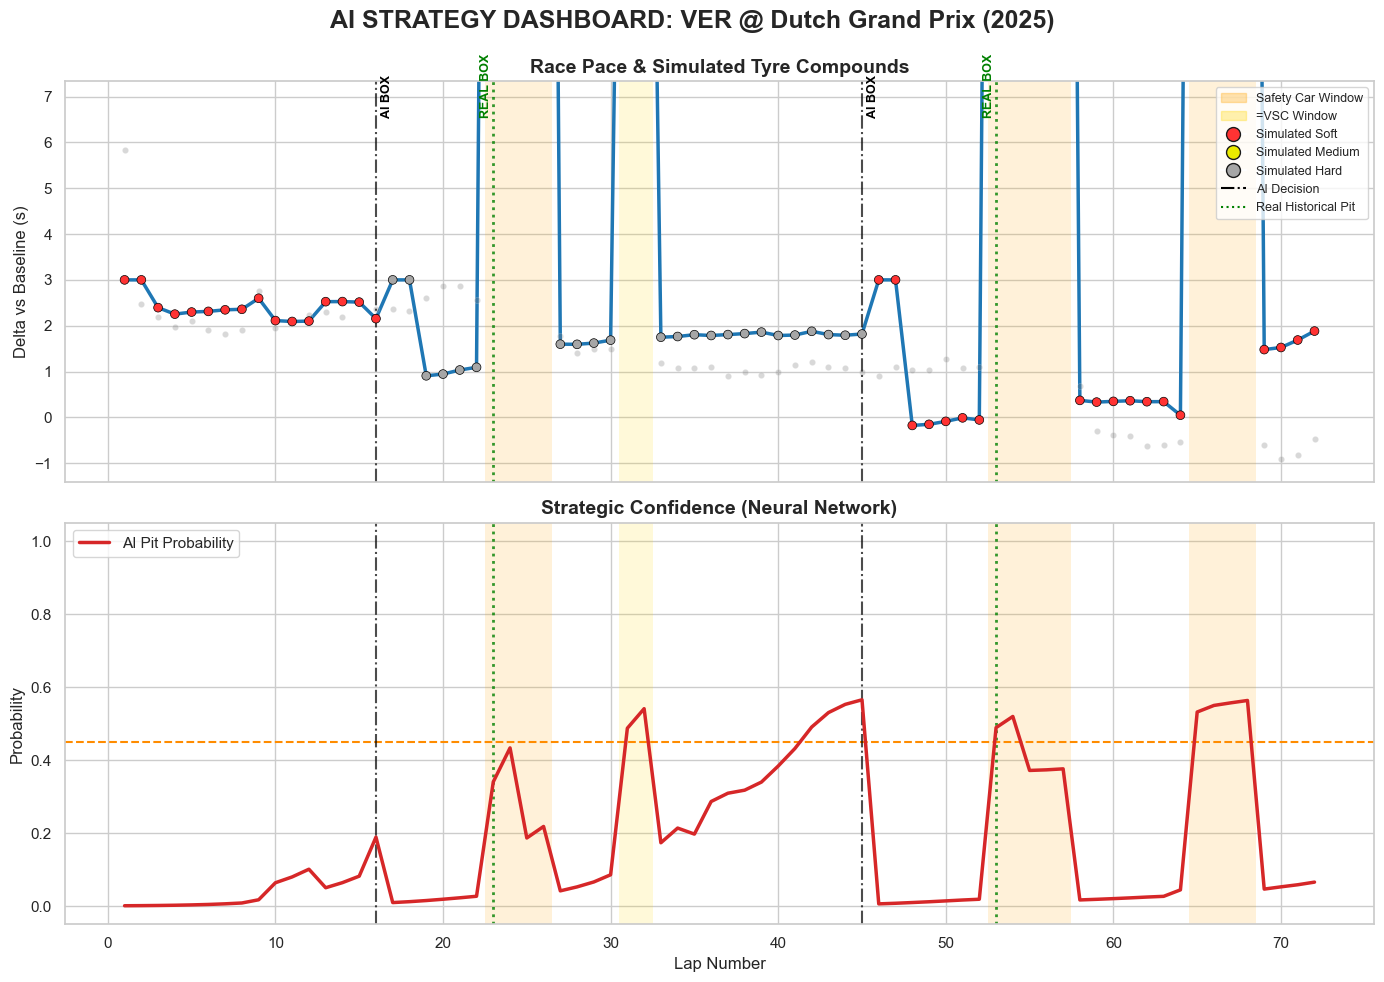

⏳ Calcolando strategia per: Emilia Romagna Grand Prix...

🟢 INIZIO GARA: Emilia Romagna Grand Prix (2025) | Pilota: VER | Mescola Partenza: MEDIUM
------------------------------------------------------------

[LAP 20] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.44
   📊 Valutazione IA: STAY_OUT: 122.2s | BOX_SOFT: 134.0s | BOX_HARD: 133.9s
   👉 Decisione Presa: STAY OUT

[LAP 21] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.51
   📊 Valutazione IA: STAY_OUT: 119.5s | BOX_SOFT: 131.7s | BOX_HARD: 135.0s
   👉 Decisione Presa: STAY OUT

[LAP 22] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.57
   📊 Valutazione IA: STAY_OUT: 116.3s | BOX_SOFT: 129.2s | BOX_HARD: 117.2s
   👉 Decisione Presa: STAY OUT

[LAP 23] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.60
   📊 Valutazione IA: STAY_OUT: 113.1s | BOX_SOFT: 127.1s | BOX_HARD: 114.0s
   👉 Decisione Presa: STAY OUT

[LAP 24] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabil

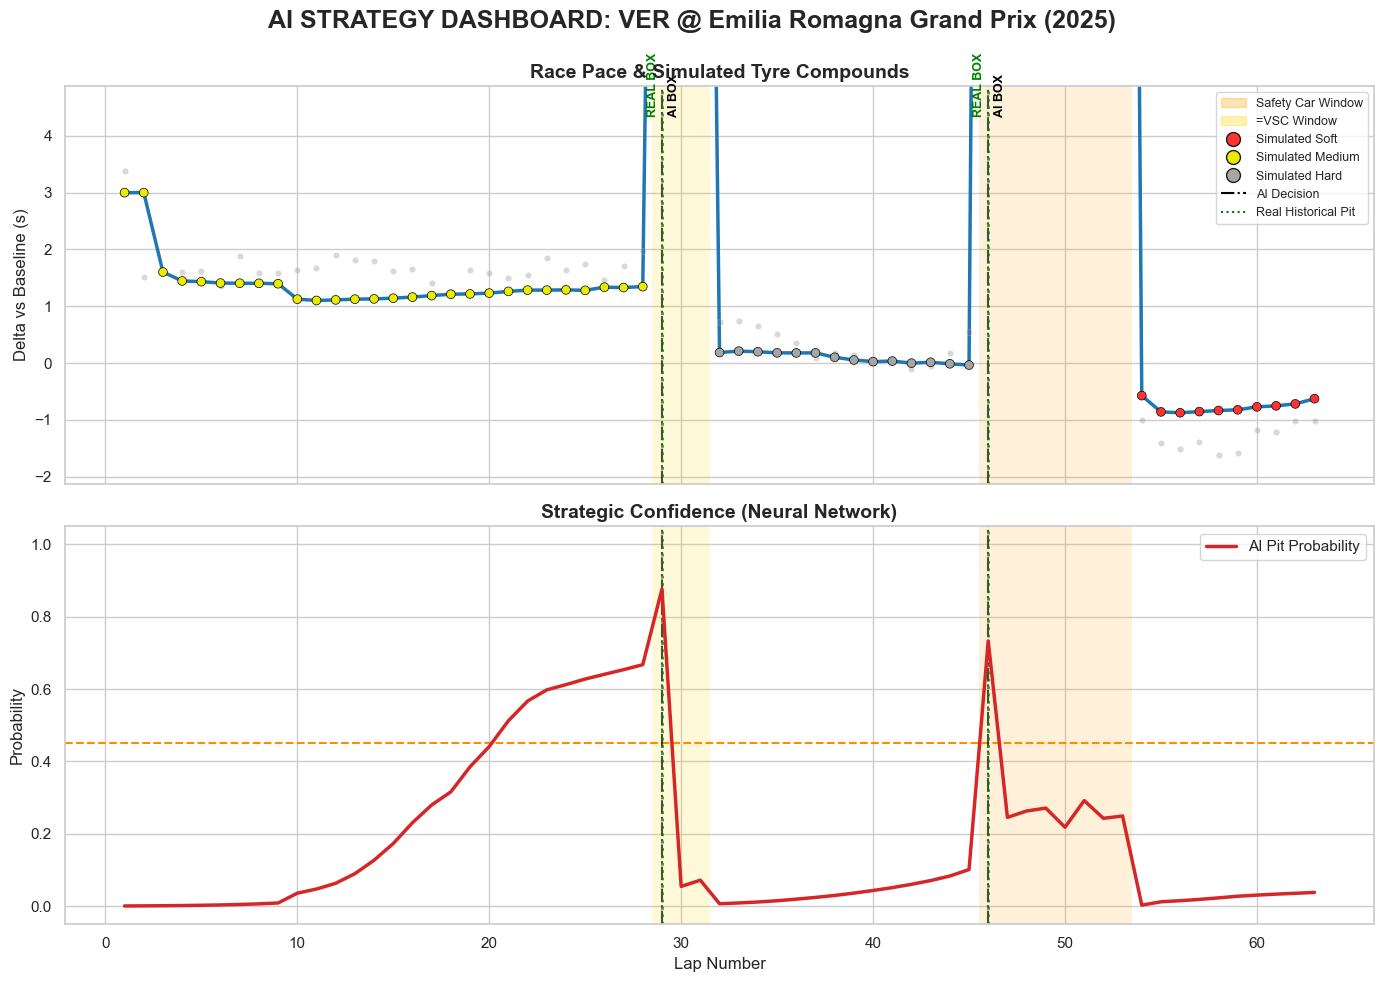


🏆 CAMPIONATO SIMULATO CON SUCCESSO!


In [15]:
# full races
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ PANNELLO DI CONTROLLO
# ==========================================
TARGET_DRIVER = 'VER'
TARGET_YEAR = 2025
TARGET_DF = df_race
# ==========================================

# ==========================================
# ⚙️ IMPOSTAZIONI INTERVALLO GARE
# ==========================================
START_IDX = 3  # Indice di partenza
END_IDX = 5    # Indice di fine (escluso)
# ==========================================

# 1. Trova tutte le gare completate
df_target = TARGET_DF[(TARGET_DF['Year'] == TARGET_YEAR) & (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1)]
completed_gps = []

for gp_name, gp_data in df_target.groupby('GP'):
    if gp_data['RaceProgress'].max() >= 0.99:
        completed_gps.append(gp_name)

# 2. Taglia la lista tenendo solo l'intervallo scelto
completed_gps = completed_gps[START_IDX:END_IDX]

print(f"🏁 Trovate le gare nell'intervallo scelto ({START_IDX} - {END_IDX}):")
print(completed_gps)
print(f"🏁 INIZIO TEST GLOBALE SU {len(completed_gps)} GRAN PREMI...\n")

simulations = []

# 3. Esegui la simulazione gara per gara
for gp in completed_gps:
    print(f"⏳ Calcolando strategia per: {gp}...")
    
    sim_df = run_stochastic_dynamic_strategy_test(
        TARGET_DF, gp, TARGET_DRIVER, TARGET_YEAR, 
        nn_model, best_xgb_model, xgb_features, nn_features, sc_prob_matrix
    )
    
    if sim_df is not None:
        print(f"✅ Gara {gp} completata. Generazione grafico e resoconto...")
        
        # =========================================================
        # 📝 STAMPA DEL RESOCONTO STRATEGICO (Solo Pit Stops)
        # =========================================================
        pit_stops = sim_df[sim_df['Action'].str.contains("BOX")]
        
        print("\n" + "="*60)
        print(f"📋 RESOCONTO STRATEGICO UFFICIALE: {gp.upper()}")
        print("="*60)
        
        if pit_stops.empty:
            print(" ❌ Nessun Pit Stop effettuato (Strategia a 0 soste o gara interrotta).")
        else:
            for _, row in pit_stops.iterrows():
                lap = row['Lap']
                action = row['Action']
                prob = row['AI_Pit_Prob']
                sc_risk = row.get('SC_Risk_Prob', 0.0)
                
                # Prende i tempi gestendo eventuali valori nulli
                t_stay = row.get('Time_If_Stay_Out', 0)
                t_soft = row.get('Time_If_Box_Soft', 0)
                t_med  = row.get('Time_If_Box_Medium', 0)
                t_hard = row.get('Time_If_Box_Hard', 0)
                
                print(f"▶ GIRO {lap} | Decisione: {action}")
                print(f"  ├ Gomma smontata: {row['Sim_Compound']} (Età: {row['Sim_TyreAge_StartOfLap']} giri)")
                print(f"  ├ Alert Rete Neurale: {prob:.2f} | Rischio Statistico SC: {sc_risk:.1%}")
                print(f"  └ Proiezioni IA (Expected Value a fine gara):")
                print(f"      STAY OUT : {t_stay:.1f}s")
                print(f"      BOX SOFT : {t_soft:.1f}s")
                print(f"      BOX MED  : {t_med:.1f}s")
                print(f"      BOX HARD : {t_hard:.1f}s")
                print("-" * 60)
        print("\n")
        # =========================================================

        real_df = TARGET_DF[(TARGET_DF['GP'] == gp) & 
                            (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1) & 
                            (TARGET_DF['Year'] == TARGET_YEAR)]
        
        plot_simulation_vs_reality_v2(
            sim_df=sim_df, 
            real_df=real_df, 
            driver_code=TARGET_DRIVER, 
            gp_name=gp, 
            year=TARGET_YEAR
        )
        plt.show() 

    simulations.append(sim_df)
    
print("\n🏆 CAMPIONATO SIMULATO CON SUCCESSO!")

🏁 Trovate le gare nell'intervallo scelto (3 - 5):
['Dutch Grand Prix', 'Emilia Romagna Grand Prix']
🏁 INIZIO TEST GLOBALE SU 2 GRAN PREMI...

⏳ Calcolando strategia per: Dutch Grand Prix...

🟢 INIZIO GARA: Dutch Grand Prix (2025) | Pilota: PIA | Mescola Partenza: MEDIUM
------------------------------------------------------------

[LAP 8] 📻 TEAM RADIO
   📊 Valutazione IA: STAY_OUT: 229.3s | BOX_SOFT: 229.7s | BOX_HARD: 228.2s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 23] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   🚨 NN VETO ACTIVATED (Prob: 0.75) - STAY OUT scartato per difesa!
   📊 Valutazione IA: BOX_SOFT: 257.1s | BOX_MEDIUM: 281.4s
   👉 Decisione Presa: BOX (SAFETY CAR)

[LAP 31] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   📊 Valutazione IA: STAY_OUT: 222.7s | BOX_MEDIUM: 244.2s | BOX_HARD: 246.9s
   👉 Decisione Presa: STAY OUT

[LAP 48] 📻 TEAM RADIO
   📊 Valutazione IA: STAY_OUT: 91.2s | BOX_MEDIUM: 91.2s | BOX_HARD: 99.3s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 53] 📻 T

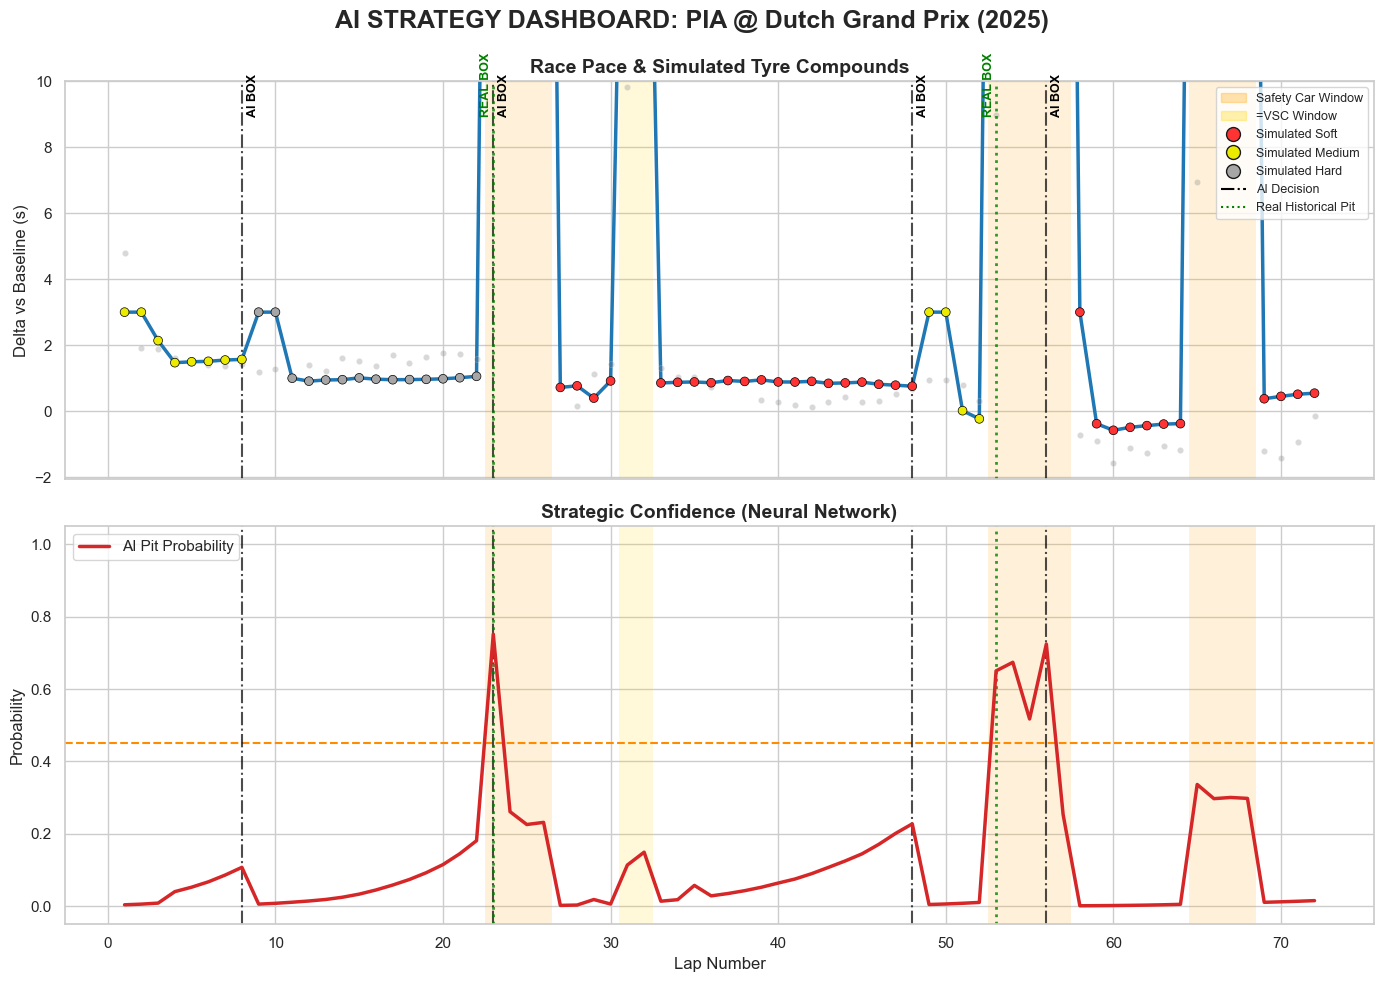

⏳ Calcolando strategia per: Emilia Romagna Grand Prix...

🟢 INIZIO GARA: Emilia Romagna Grand Prix (2025) | Pilota: PIA | Mescola Partenza: MEDIUM
------------------------------------------------------------

[LAP 14] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.58
   📊 Valutazione IA: STAY_OUT: 159.4s | BOX_SOFT: 161.3s | BOX_HARD: 184.8s
   👉 Decisione Presa: STAY OUT

[LAP 15] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.59
   📊 Valutazione IA: STAY_OUT: 155.8s | BOX_SOFT: 158.2s | BOX_HARD: 156.6s
   👉 Decisione Presa: STAY OUT

[LAP 16] 📻 TEAM RADIO
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.47
   📊 Valutazione IA: STAY_OUT: 153.3s | BOX_SOFT: 155.2s | BOX_HARD: 153.0s
   👉 Decisione Presa: BOX (STRATEGY)

[LAP 29] 📻 TEAM RADIO
   🟡 SAFETY CAR / VSC DEPLOYED!
   🧠 Alert Rete Neurale: Probabilità Pit Stop al 0.45
   📊 Valutazione IA: STAY_OUT: 193.1s | BOX_SOFT: 206.5s | BOX_MEDIUM: 183.4s
   👉 Decisione Presa: BOX (SAFETY CAR)

[LAP 46

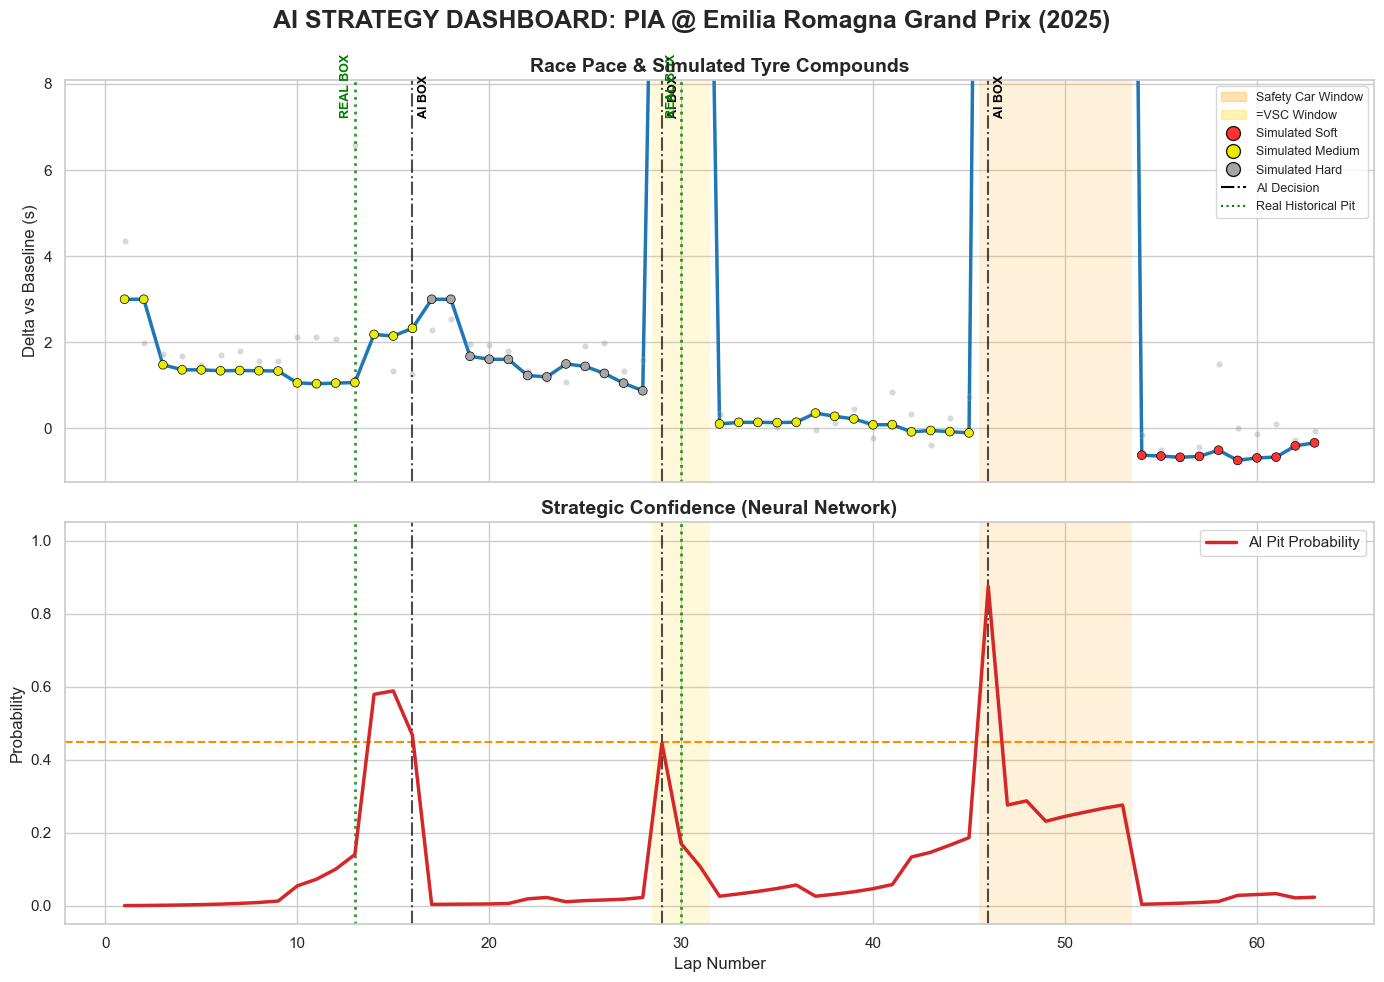


🏆 CAMPIONATO SIMULATO CON SUCCESSO!


In [16]:
# full races
import matplotlib.pyplot as plt

# ==========================================
# ⚙️ PANNELLO DI CONTROLLO
# ==========================================
TARGET_DRIVER = 'PIA'
TARGET_YEAR = 2025
TARGET_DF = df_race
# ==========================================

# ==========================================
# ⚙️ IMPOSTAZIONI INTERVALLO GARE
# ==========================================
START_IDX = 3  # Indice di partenza
END_IDX = 5    # Indice di fine (escluso)
# ==========================================

# 1. Trova tutte le gare completate
df_target = TARGET_DF[(TARGET_DF['Year'] == TARGET_YEAR) & (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1)]
completed_gps = []

for gp_name, gp_data in df_target.groupby('GP'):
    if gp_data['RaceProgress'].max() >= 0.99:
        completed_gps.append(gp_name)

# 2. Taglia la lista tenendo solo l'intervallo scelto
completed_gps = completed_gps[START_IDX:END_IDX]

print(f"🏁 Trovate le gare nell'intervallo scelto ({START_IDX} - {END_IDX}):")
print(completed_gps)
print(f"🏁 INIZIO TEST GLOBALE SU {len(completed_gps)} GRAN PREMI...\n")

simulations = []

# 3. Esegui la simulazione gara per gara
for gp in completed_gps:
    print(f"⏳ Calcolando strategia per: {gp}...")
    
    sim_df = run_stochastic_dynamic_strategy_test(
        TARGET_DF, gp, TARGET_DRIVER, TARGET_YEAR, 
        nn_model, best_xgb_model, xgb_features, nn_features, sc_prob_matrix
    )
    
    if sim_df is not None:
        print(f"✅ Gara {gp} completata. Generazione grafico e resoconto...")
        
        # =========================================================
        # 📝 STAMPA DEL RESOCONTO STRATEGICO (Solo Pit Stops)
        # =========================================================
        pit_stops = sim_df[sim_df['Action'].str.contains("BOX")]
        
        print("\n" + "="*60)
        print(f"📋 RESOCONTO STRATEGICO UFFICIALE: {gp.upper()}")
        print("="*60)
        
        if pit_stops.empty:
            print(" ❌ Nessun Pit Stop effettuato (Strategia a 0 soste o gara interrotta).")
        else:
            for _, row in pit_stops.iterrows():
                lap = row['Lap']
                action = row['Action']
                prob = row['AI_Pit_Prob']
                sc_risk = row.get('SC_Risk_Prob', 0.0)
                
                # Prende i tempi gestendo eventuali valori nulli
                t_stay = row.get('Time_If_Stay_Out', 0)
                t_soft = row.get('Time_If_Box_Soft', 0)
                t_med  = row.get('Time_If_Box_Medium', 0)
                t_hard = row.get('Time_If_Box_Hard', 0)
                
                print(f"▶ GIRO {lap} | Decisione: {action}")
                print(f"  ├ Gomma smontata: {row['Sim_Compound']} (Età: {row['Sim_TyreAge_StartOfLap']} giri)")
                print(f"  ├ Alert Rete Neurale: {prob:.2f} | Rischio Statistico SC: {sc_risk:.1%}")
                print(f"  └ Proiezioni IA (Expected Value a fine gara):")
                print(f"      STAY OUT : {t_stay:.1f}s")
                print(f"      BOX SOFT : {t_soft:.1f}s")
                print(f"      BOX MED  : {t_med:.1f}s")
                print(f"      BOX HARD : {t_hard:.1f}s")
                print("-" * 60)
        print("\n")
        # =========================================================

        real_df = TARGET_DF[(TARGET_DF['GP'] == gp) & 
                            (TARGET_DF[f'Driver_{TARGET_DRIVER}'] == 1) & 
                            (TARGET_DF['Year'] == TARGET_YEAR)]
        
        plot_simulation_vs_reality_v2(
            sim_df=sim_df, 
            real_df=real_df, 
            driver_code=TARGET_DRIVER, 
            gp_name=gp, 
            year=TARGET_YEAR
        )
        plt.show() 

    simulations.append(sim_df)
    
print("\n🏆 CAMPIONATO SIMULATO CON SUCCESSO!")

In [4]:
df_race.query("GP == 'Emilia Romagna Grand Prix' and Year == 2025 and Driver_PIA == 1")

,LapNumber,Team,Position,InPits,TrackTemp,Year,GP,RaceProgress,TyreLifeProgress,CarClose,...,Driver_RAI,Driver_RIC,Driver_RUS,Driver_SAI,Driver_SAR,Driver_STR,Driver_TSU,Driver_VER,Driver_VET,Driver_ZHO
97026,1.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.015873,0.029412,1,...,0,0,0,0,0,0,0,0,0,0
97046,2.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.031746,0.058824,1,...,0,0,0,0,0,0,0,0,0,0
97066,3.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.047619,0.088235,1,...,0,0,0,0,0,0,0,0,0,0
97086,4.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.063492,0.117647,1,...,0,0,0,0,0,0,0,0,0,0
97106,5.0,McLaren,2.0,0,42.664,2025,Emilia Romagna Grand Prix,0.079365,0.147059,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98142,59.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.936508,0.828571,0,...,0,0,0,0,0,0,0,0,0,0
98160,60.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.952381,0.857143,0,...,0,0,0,0,0,0,0,0,0,0
98178,61.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.968254,0.885714,0,...,0,0,0,0,0,0,0,0,0,0
98196,62.0,McLaren,3.0,0,42.664,2025,Emilia Romagna Grand Prix,0.984127,0.914286,1,...,0,0,0,0,0,0,0,0,0,0


# CORRELATION  

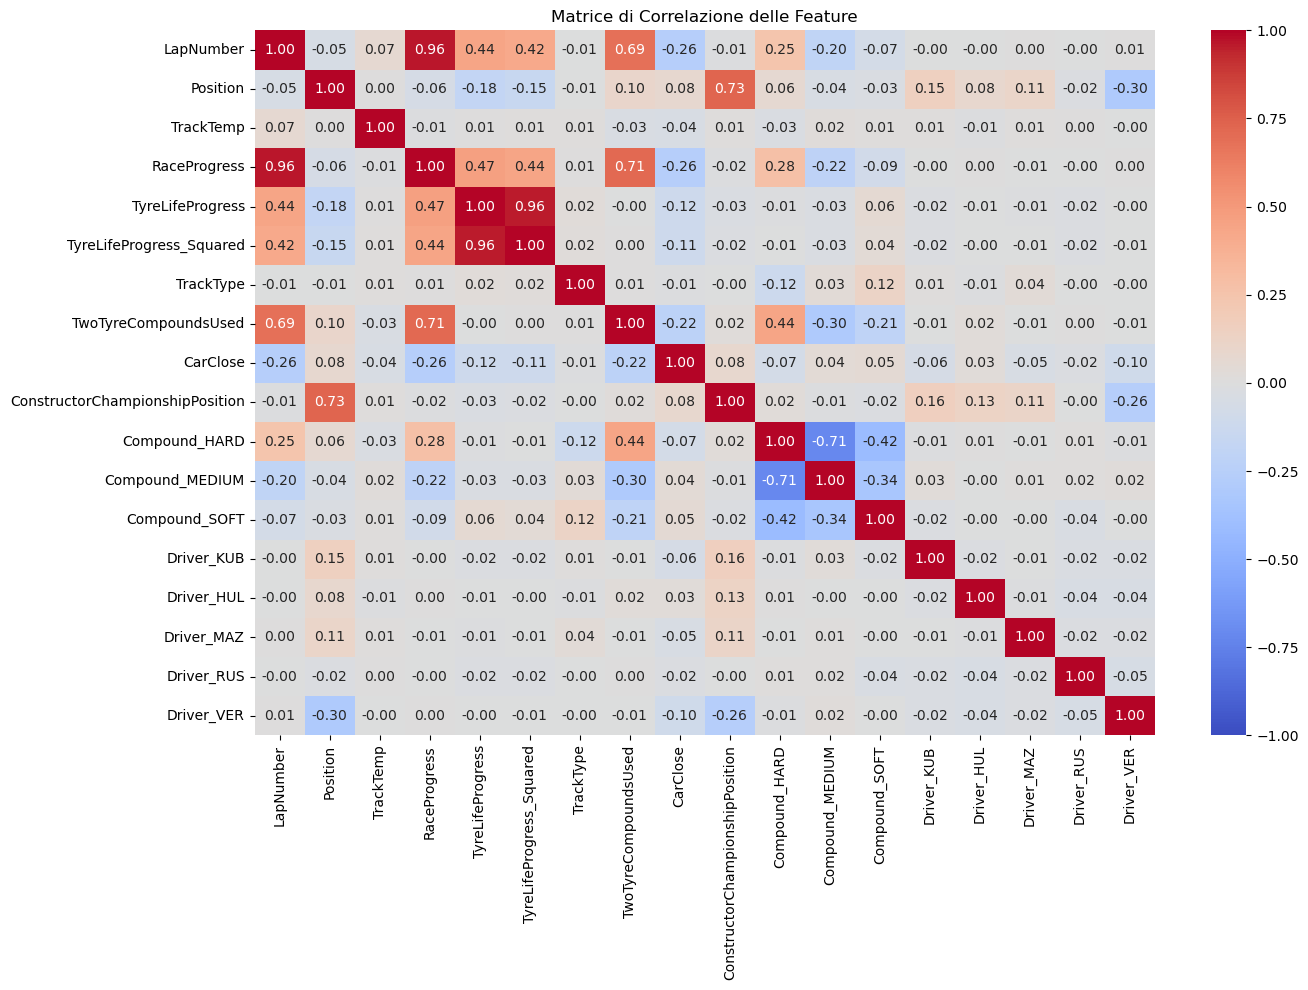

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcola la matrice di correlazione
corr_matrix = df_race[xgb_cols_to_keep + ['Driver_KUB', 'Driver_HUL', 'Driver_MAZ', 'Driver_RUS', 'Driver_VER']].corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1)
plt.title('Matrice di Correlazione delle Feature')
plt.tight_layout()
plt.show()

In [5]:
from scipy import stats
corr, pvalue = stats.pointbiserialr(df_race['ConstructorChampionshipPosition'], df_race['Driver_KUB'])
print(f'Correlazione: {corr:.3f}, p-value: {pvalue:.4f}')

Correlazione: 0.159, p-value: 0.0000
